In [69]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [125]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, AddErrors2021Preprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
end_time = None
early_percentage = None
assignment_ids = None
compile_error_type_col = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError

edwards2019_config = {
    "config_path": "sample_data_configs/edwards2019.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        SortPreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    # "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.23,
    # "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "exam2",
}

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        # Don't need this, since I've done and cached it
        # AddErrors2021Preprocessor(),
        TimeStampToDateTimePreprocessor(),
        SortPreprocessor(),
    ],
    # Compile error info is stored in the Run.Program event itself
    "compile_event": EventType.RunProgram,
    "end_time": "2022-01-01 00:00:00",
    "early_percentage": 0.23,
    "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
    "grades_col": "FinalScore",
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "main_table_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

# config = cwo_f19_config
# config = codebench2024_config
config = edwards2021_config
locals().update(config)

In [126]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [127]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [128]:
main_table = dataset.get_main_table()
main_table.head()

c:\Users\twprice\Documents\GitHub\ProgSnap2\src\database\reader\csv_reader.py:20: DtypeWarning: Columns (0,3,6,7,8,11,12,13,14,15,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,EventID,SubjectID,AssignmentID,CodeStateSection,X-Task,EventType,X-Keystroke,InsertText,DeleteText,SourceLocation,...,X-RunInput,X-RunOutput,X-RunHasError,X-RunUserTerminated,X-RawAssignmentID,X-Term,X-Compilable,CompileMessageType,ParentEventID,Score
4673167,8410070,S479,p4s,task1.py,1.0,X-SwitchTask,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,p4,s,1.0,NaN,NaN,NaN
4673168,8410071,S479,p4s,task1.py,1.0,File.Edit,NaN,# Don't forget comments that go here\n\n\n,NaN,0.0,...,NaN,NaN,NaN,NaN,p4,s,1.0,NaN,NaN,NaN
4673169,8410072,S479,p4s,task0.py,0.0,X-SwitchTask,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,p4,s,1.0,NaN,NaN,NaN
4673170,8410073,S479,p4s,task0.py,0.0,File.Edit,NaN,# Don't forget comments that go here\n,NaN,0.0,...,NaN,NaN,NaN,NaN,p4,s,1.0,NaN,NaN,NaN
4673171,8410074,S479,p4s,task0.py,0.0,File.Edit,i,i,NaN,37.0,...,NaN,NaN,NaN,NaN,p4,s,1.0,NaN,NaN,NaN


In [74]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [75]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]
if end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= end_time]

In [76]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

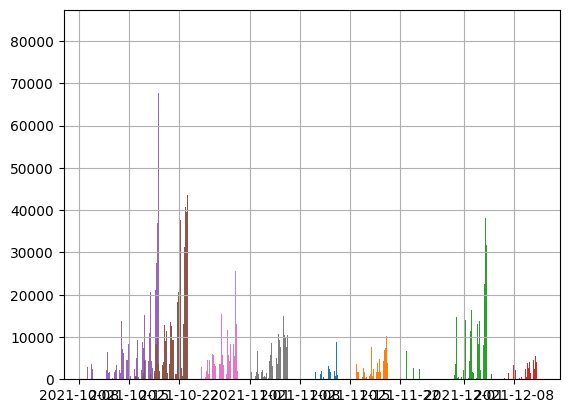

In [77]:
if "X-ClassID" not in main_table.columns:
    main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [78]:
import numpy as np
for i in main_table[timestamp_col].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2021-10-08 23:04:57.176999936+00:00
2021-10-12 00:08:26.073999872+00:00
2021-10-13 04:39:47.626599936+00:00
2021-10-13 22:27:50.726259968+00:00
2021-10-14 03:02:32.646560+00:00
2021-10-14 20:59:46.925600+00:00
2021-10-15 04:39:16.330499840+00:00
2021-10-16 05:50:38.416470016+00:00
2021-10-16 22:10:42.049039872+00:00
2021-10-17 01:06:26.611889920+00:00
2021-10-17 04:28:10.842199808+00:00
2021-10-17 21:12:02.591000064+00:00
2021-10-17 23:11:52.445319936+00:00
2021-10-18 15:30:44.132419840+00:00
2021-10-18 17:34:01.110380032+00:00
2021-10-18 19:00:01.759049984+00:00
2021-10-18 20:33:04.909319936+00:00
2021-10-18 21:56:30.601569792+00:00
2021-10-18 23:17:43.599559936+00:00
2021-10-19 00:22:40.576899840+00:00
2021-10-19 01:43:32.840199936+00:00
2021-10-19 02:32:45.050409984+00:00
2021-10-19 03:11:30.901779968+00:00
2021-10-19 03:34:37.564100096+00:00
2021-10-19 03:58:50.915559936+00:00
2021-10-19 04:43:49.072000+00:00
2021-10-19 05:18:29.663059968+00:00
2021-10-19 17:54:39.877430016+00:00
2

In [79]:
#get the data of the third quantile
max = main_table[timestamp_col].max()
min = main_table[timestamp_col].min()
range = max - min
time_cutoff = min + range * early_percentage
print(time_cutoff)
print(main_table[timestamp_col].min())
print(main_table[timestamp_col].max())

data_subset = main_table[main_table[timestamp_col] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
if Cols.ProblemID in data_subset.columns:
    print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
print("Percent of logs: ", len(data_subset) / len(main_table) * 100)
print("Percent of assignments: ", len(data_subset[Cols.AssignmentID].unique()) / len(main_table[Cols.AssignmentID].unique()) * 100)
if Cols.ProblemID in main_table.columns:
    print("Percent of problems: ", len(data_subset[Cols.ProblemID].unique()) / len(main_table[Cols.ProblemID].unique()) * 100)
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2021-10-23 12:38:36.347540+00:00
2021-10-08 23:04:57.177000+00:00
2021-12-11 06:54:44.875000+00:00
Assignment IDs: ['Assign6' 'Assign7' 'Assign8']
Total number of rows: 924633
Percent of logs:  44.13055036650054
Percent of assignments:  37.5


In [80]:
if assignment_ids is not None:
    data_subset = data_subset[data_subset[Cols.AssignmentID].isin(assignment_ids)]

In [81]:
testing_student_subset = data_subset[Cols.SubjectID].unique()[:50]
testing_mt_subset = data_subset[data_subset[Cols.SubjectID].isin(testing_student_subset)]

In [82]:
grouping_cols = ["X-ClassID", Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [83]:
main_table.EventType[~main_table[compile_error_type_col].isna()].value_counts()

EventType
Compile.Error    5936
Name: count, dtype: int64

In [84]:
from analytics.metrics.errors import ErrorMetrics


error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_col,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_17200\4122987523.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  RepeatedErrorDensity  \
SubjectID AssignmentID                                        
Student1  Assign6                 0.0                   0.0   
          Assign7                 0.0                   0.0   
Student10 Assign6                 0.0                   0.0   
          Assign7                 0.0                   0.0   
Student11 Assign6                 0.0                   0.0   

                        FailedCompileCount  
SubjectID AssignmentID                      
Student1  Assign6                      5.0  
          Assign7                     10.0  
Student10 Assign6                      9.0  
          Assign7                     32.0  
Student11 Assign6                      8.0

In [85]:
# Investigating a single Edwards 2021 student to see why EQ/RED are so low
# Errors tend not to be repeated and there are many successful runs
# data_subset[
#     (data_subset[Cols.SubjectID] == "Student1") &
#     (data_subset[Cols.AssignmentID] == "Assign7") &
#     ((data_subset[Cols.EventType] == EventType.CompileError) | (data_subset[Cols.EventType] == EventType.RunProgram))
# ].head(40)

In [86]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,77.000000,77.000000,78.000000
mean,0.000175,0.012987,28.512821
std,0.000958,0.080050,39.875372
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,6.000000
50%,0.000000,0.000000,13.000000
75%,0.000000,0.000000,32.750000
max,0.007737,0.500000,216.000000


In [87]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.678201,0.258255
RepeatedErrorDensity,0.678201,1.000000,0.268347
FailedCompileCount,0.258255,0.268347,1.000000


<Axes: ylabel='Frequency'>

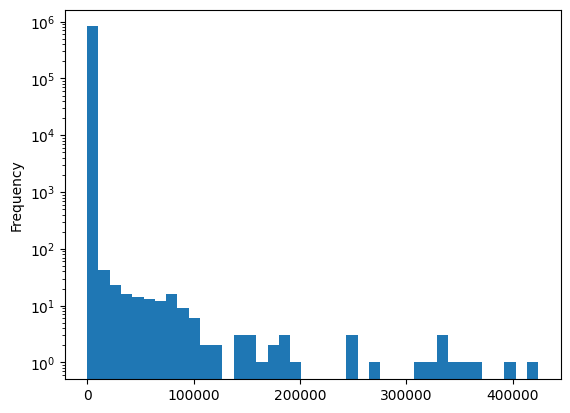

In [88]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(testing_mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [89]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00       0.000017
0.25       0.000117
0.50       0.001433
0.75       0.004750
0.80       0.007300
0.85       0.012000
0.90       0.022933
0.95       0.058600
0.96       0.079583
0.97       0.118613
0.98       0.206117
0.99       0.481883
1.00    7062.422967
Name: DeltaSeconds, dtype: float64

In [90]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_17200\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
SubjectID AssignmentID                                       
Student1  Assign6         4070.057     3961.911   8031.968   
          Assign7         2824.285     2617.328   5441.613   
Student10 Assign6         4461.497     2510.514   6972.011   
          Assign7         4303.607     2883.756   7187.363   
Student11 Assign6         4017.941     2718.629   6736.570   
...                            ...          ...        ...   
Student7  Assign7         4396.574     1903.645   6300.219   
Student8  Assign6         4575.533     2151.829   6727.362   
          Assign7         5069.805     3451.084   8520.889   
Student9  Assign6         7755.097     5634.013  13389.110   
          Assign7        14471.103     8300.890  22771.993   

                        ActiveTimeAfterCorrect  #Breaks  \
SubjectID AssignmentID                                    
Student1  Assign6                          0.0       22   
          Assign7                          0.0       18   
Student10 Assign6                          0.0       22   
          Assign7                          0.0       13   
Student11 Assign6                          0.0       17   
...                                        ...      ...   
Student7  Assign7                          0.0       14   
Student8  Assign6                          0.0        8   
          Assign7                          0.0        9   
Student9  Assign6                          0.0       11   
          Assign7                          0.0       28   

                                              StartTime  \
SubjectID AssignmentID                                    
Student1  Assign6      2021-10-18 04:36:30.335000+00:00   
          Assign7      2021-10-20 05:51:20.838000+00:00   
Student10 Assign6      2021-10-10 18:13:46.376000+00:00   
          Assign7      2021-10-21 02:57:43.909000+00:00   
Student11 Assign6      2021-10-16 18:34:05.710000+00:00   
...                                                 ...   
Student7  Assign7      2021-10-18 00:22:40.671000+00:00   
Student8  Assign6      2021-10-18 16:00:54.951000+00:00   
          Assign7      2021-10-20 18:35:20.667000+00:00   
Student9  Assign6      2021-10-18 20:57:40.382000+00:00   
          Assign7      2021-10-20 17:35:38.487000+00:00   

                                       FirstCorrectTime  \
SubjectID AssignmentID                                    
Student1  Assign6      2021-10-19 05:53:30.844000+00:00   
          Assign7      2021-10-22 05:46:11.558000+00:00   
Student10 Assign6      2021-10-14 23:38:06.118000+00:00   
          Assign7      2021-10-22 20:17:27.192000+00:00   
Student11 Assign6                                   NaT   
...                                                 ...   
Student7  Assign7      2021-10-22 03:32:38.294000+00:00   
Student8  Assign6      2021-10-19 03:51:06.128000+00:00   
          Assign7                                   NaT   
Student9  Assign6      2021-10-19 05:50:29.926000+00:00   
          Assign7      2021-10-23 03:23:32.406000+00:00   

                                                EndTime  
SubjectID AssignmentID                                   
Student1  Assign6      2021-10-19 05:53:30.844000+00:00  
          Assign7      2021-10-22 05:46:11.558000+00:00  
Student10 Assign6      2021-10-14 23:38:06.118000+00:00  
          Assign7      2021-10-22 20:17:27.192000+00:00  
Student11 Assign6      2021-10-18 01:27:56.184000+00:00  
...                                                 ...  
Student7  Assign7      2021-10-22 03:32:38.294000+00:00  
Student8  Assign6      2021-10-19 03:51:06.128000+00:00  
          Assign7      2021-10-23 01:01:44.361000+00:00  
Student9  Assign6      2021-10-19 05:50:29.926000+00:00  
          Assign7      2021-10-23 03:23:32.406000+00:00  

[78 rows x 8 columns]

In [91]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks
count,78.000000,78.000000,78.000000,78.0,78.000000
mean,6763.587705,5413.845885,12177.433590,0.0,21.153846
std,3970.226101,3289.069703,6979.505973,0.0,14.974504
min,2.786000,0.000000,2.786000,0.0,1.000000
25%,4030.970000,2929.491000,7198.800500,0.0,11.000000
50%,6318.867000,4889.300500,11185.741500,0.0,17.500000
75%,8766.416250,7353.448750,16226.556750,0.0,27.500000
max,25022.087000,17697.087000,42719.174000,0.0,79.000000


In [92]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_17200\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [93]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  Attempted  \
SubjectID AssignmentID                                                   
Student1  Assign6              1          True         True       True   
          Assign7              1          True         True       True   
Student10 Assign6              1          True         True       True   
          Assign7              1          True         True       True   
Student11 Assign6              0         False        False      False   

                        MaxScore  MinScore  MeanScore  TotalAttempts  
SubjectID AssignmentID                                                
Student1  Assign6           99.0      99.0       99.0              1  
          Assign7           99.0      99.0       99.0              1  
Student10 Assign6           95.0      95.0       95.0              1  
          Assign7          100.0     100.0      100.0              1  
Student11 Assign6            0.0       0.0        0.0              0

In [94]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,78.000000,75.000000,75.000000,75.000000,78.000000
mean,0.974359,74.880000,74.880000,74.880000,0.974359
std,0.159085,34.108416,34.108416,34.108416,0.159085
min,0.000000,-50.000000,-50.000000,-50.000000,0.000000
25%,1.000000,68.000000,68.000000,68.000000,1.000000
50%,1.000000,89.000000,89.000000,89.000000,1.000000
75%,1.000000,99.500000,99.500000,99.500000,1.000000
max,1.000000,100.000000,100.000000,100.000000,1.000000


In [96]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features = pd.merge(
    all_features,
    error_results.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,Student1,Assign6,4070.057,3961.911,8031.968,0.0,22,2021-10-18 04:36:30.335000+00:00,2021-10-19 05:53:30.844000+00:00,2021-10-19 05:53:30.844000+00:00,...,True,True,True,99.0,99.0,99.0,1,0.0,0.0,5.0
1,Student1,Assign7,2824.285,2617.328,5441.613,0.0,18,2021-10-20 05:51:20.838000+00:00,2021-10-22 05:46:11.558000+00:00,2021-10-22 05:46:11.558000+00:00,...,True,True,True,99.0,99.0,99.0,1,0.0,0.0,10.0
2,Student10,Assign6,4461.497,2510.514,6972.011,0.0,22,2021-10-10 18:13:46.376000+00:00,2021-10-14 23:38:06.118000+00:00,2021-10-14 23:38:06.118000+00:00,...,True,True,True,95.0,95.0,95.0,1,0.0,0.0,9.0
3,Student10,Assign7,4303.607,2883.756,7187.363,0.0,13,2021-10-21 02:57:43.909000+00:00,2021-10-22 20:17:27.192000+00:00,2021-10-22 20:17:27.192000+00:00,...,True,True,True,100.0,100.0,100.0,1,0.0,0.0,32.0
4,Student11,Assign6,4017.941,2718.629,6736.570,0.0,17,2021-10-16 18:34:05.710000+00:00,NaT,2021-10-18 01:27:56.184000+00:00,...,False,False,False,0.0,0.0,0.0,0,0.0,0.0,8.0


In [97]:
all_features.isna().mean()

SubjectID                 0.000000
AssignmentID              0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.115385
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.038462
MinScore                  0.038462
MeanScore                 0.038462
TotalAttempts             0.000000
ErrorQuotient             0.012821
RepeatedErrorDensity      0.012821
FailedCompileCount        0.000000
dtype: float64

In [98]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,78.000000,78.000000,78.000000,78.0,78.000000,78.000000,75.000000,75.000000,75.000000,78.000000,77.000000,77.000000,78.000000,78.000000,78.000000,78.000000
mean,6763.587705,5413.845885,12177.433590,0.0,21.153846,0.974359,74.880000,74.880000,74.880000,0.974359,0.000175,0.012987,28.512821,0.512821,0.500000,0.743590
std,3970.226101,3289.069703,6979.505973,0.0,14.974504,0.159085,34.108416,34.108416,34.108416,0.159085,0.000958,0.080050,39.875372,0.503071,0.503236,0.439477
min,2.786000,0.000000,2.786000,0.0,1.000000,0.000000,-50.000000,-50.000000,-50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4030.970000,2929.491000,7198.800500,0.0,11.000000,1.000000,68.000000,68.000000,68.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.250000
50%,6318.867000,4889.300500,11185.741500,0.0,17.500000,1.000000,89.000000,89.000000,89.000000,1.000000,0.000000,0.000000,13.000000,1.000000,0.500000,1.000000
75%,8766.416250,7353.448750,16226.556750,0.0,27.500000,1.000000,99.500000,99.500000,99.500000,1.000000,0.000000,0.000000,32.750000,1.000000,1.000000,1.000000
max,25022.087000,17697.087000,42719.174000,0.0,79.000000,1.000000,100.000000,100.000000,100.000000,1.000000,0.007737,0.500000,216.000000,1.000000,1.000000,1.000000


In [99]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [100]:
all_features_z.head()

,SubjectID,AssignmentID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Student1,Assign6,-0.769725,-0.363766,-0.601434,0.0,0.000000,0.736089,0.435813,0.524285,...,0.831530,0.831530,0.831530,0.152499,0.000000,0.000000,-0.521995,-1.011561,1.059838,0.614894
1,Student1,Assign7,-0.895733,-0.896751,-0.919061,0.0,-0.153606,-0.203139,0.242628,-0.348347,...,0.565510,0.565510,0.565510,0.169031,-0.278279,-0.246296,-0.783358,-1.014185,0.904458,0.536499
2,Student10,Assign6,-0.640114,-0.849445,-0.788287,0.0,0.000000,-1.787346,0.435722,-3.988080,...,0.722655,0.722655,0.722655,0.152499,0.000000,0.000000,-0.184465,-1.011561,1.059838,0.614894
3,Student10,Assign7,-0.594064,-0.823119,-0.708979,0.0,-0.516863,0.257428,0.242648,0.172519,...,0.599228,0.599228,0.599228,0.169031,-0.278279,-0.246296,-0.350346,-1.014185,0.904458,0.536499
4,Student11,Assign6,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476


In [101]:
all_features_z.RepeatedErrorDensity.isna().mean()

np.float64(0.01282051282051282)

In [102]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

SubjectID
Student5    True
Name: ErrorQuotient, dtype: bool

In [103]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

,EventID,SubjectID,AssignmentID,CodeStateSection,EventType,SourceLocation,EditType,InsertText,DeleteText,X-Metadata,ClientTimestamp,ToolInstances,CodeStateID,X-Compilable,CompileMessageData,CompileMessageType,ParentEventID,Score
1842030,1842030,Student5,Assign7,chessboard.py,X-Attention,175448.0,NaN,NaN,NaN,Lockout,2021-10-21 20:23:29.546000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842031,1842031,Student5,Assign7,chessboard.py,X-Attention,175448.0,NaN,NaN,NaN,ON,2021-10-21 20:23:31.198000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842032,1842032,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,223,2021-10-21 21:08:28.177000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842033,1842033,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,222,2021-10-21 21:08:28.185000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842034,1842034,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,219,2021-10-21 21:08:28.210000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842457,1842457,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,223,2021-10-21 21:08:54.267000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842458,1842458,Student5,Assign7,task1.py,X-ReplayAction,NaN,NaN,NaN,NaN,223,2021-10-21 21:08:54.856000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842459,1842459,Student5,Assign7,task1.py,X-Attention,124474.0,NaN,NaN,NaN,Lockout,2021-10-21 22:57:00.450000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN
1842460,1842460,Student5,Assign7,task1.py,X-Attention,124474.0,NaN,NaN,NaN,OFF,2021-10-21 22:57:02.285000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN


In [112]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY, SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
Student1,-0.832729,-0.630258,-0.760247,0.0,-0.076803,0.266475,0.339220,0.087969,0.160765,1.0,...,0.698520,0.698520,0.698520,0.160765,-0.139139,-0.123148,-0.652677,-1.012873,0.982148,0.575696
Student10,-0.617089,-0.836282,-0.748633,0.0,-0.258432,-0.764959,0.339185,-1.907781,0.160765,1.0,...,0.660942,0.660942,0.660942,0.160765,-0.139139,-0.123148,-0.267405,-1.012873,0.982148,0.575696
Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,0.0,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
Student12,1.311090,2.680584,2.060824,0.0,3.048168,-0.500759,0.339231,0.343021,0.160765,1.0,...,0.232451,0.232451,0.232451,0.160765,0.348585,1.970369,2.540574,0.961711,-0.997821,0.575696
Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,1.0,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [113]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
Student1,-1.665458,-1.260517,-1.520495,0.0,-0.153606,0.532949,0.678440,0.175938,0.321529,2,...,1.397039,1.397039,1.397039,0.321529,-0.278279,-0.246296,-1.305353,-2.025746,1.964296,1.151392
Student10,-1.234178,-1.672565,-1.497266,0.0,-0.516863,-1.529919,0.678370,-3.815561,0.321529,2,...,1.321883,1.321883,1.321883,0.321529,-0.278279,-0.246296,-0.534811,-2.025746,1.964296,1.151392
Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,0,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
Student12,2.622179,5.361168,4.121647,0.0,6.096337,-1.001518,0.678463,0.686043,0.321529,2,...,0.464902,0.464902,0.464902,0.321529,0.697169,3.940737,5.081149,1.923423,-1.995642,1.151392
Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,1,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [114]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Student1,-0.832729,-0.630258,-0.760247,0.0,-0.076803,0.266475,0.339220,0.087969,0.160765,...,1.397039,1.397039,1.397039,0.321529,-0.278279,-0.246296,-1.305353,-2.025746,1.964296,1.151392
1,Student10,-0.617089,-0.836282,-0.748633,0.0,-0.258432,-0.764959,0.339185,-1.907781,0.160765,...,1.321883,1.321883,1.321883,0.321529,-0.278279,-0.246296,-0.534811,-2.025746,1.964296,1.151392
2,Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
3,Student12,1.311090,2.680584,2.060824,0.0,3.048168,-0.500759,0.339231,0.343021,0.160765,...,0.464902,0.464902,0.464902,0.321529,0.697169,3.940737,5.081149,1.923423,-1.995642,1.151392
4,Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [115]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [116]:
assert subject_features.isna().mean().mean() == 0

In [117]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049


In [118]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,SubjectID,Assign6,Assign7,Assign8,Assign9,Assign10,Assign11,Assign12,Assign13,Exam1,Exam2,Exam3,FinalScore,major,HighestACT,HighSchoolGPA
0,Student11,70.0,88.0,45.0,63.0,86.0,97.0,20.0,88.0,82.00,82.0,78.0,89.58,Non-Matriculated,NaN,NaN
1,Student23,100.0,100.0,100.0,98.0,0.0,91.0,94.0,0.0,74.00,78.0,82.0,90.98,Physics,28.0,4.000
2,Student21,90.0,96.0,98.0,95.0,77.0,0.0,97.0,56.0,68.67,78.0,80.0,90.79,Non-Matriculated,NaN,NaN
3,Student17,89.0,96.0,100.0,94.0,91.0,100.0,89.0,0.0,88.00,84.0,80.0,96.95,Statistics,26.0,3.933
4,Student7,100.0,100.0,99.5,97.0,100.0,95.0,98.0,18.0,90.00,90.0,86.0,100.52,Math/Stats - Comp Teaching,35.0,4.000


In [121]:
grades.rename(columns={
    grades_col: "Grade", "CourseID":
    # CodeBench has this mislabeled
    "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [122]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [123]:
subject_feautres_labeled.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199,97.70
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199,97.60
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049,89.58
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199,95.73
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049,94.52


In [124]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, "analysis")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, "subject_features.csv"), index=False)

41
